# BioBERT Fine-tuning for Medical Abstract Classification — PubMed 200k RCT

**Before running:** Go to `Runtime > Change Runtime Type > Hardware Accelerator > GPU`

Then run all cells from top to bottom. Do not skip any cell.

**What this notebook does:**
- Loads your pre-processed `processed_abstracts.csv` from Google Drive
- Fine-tunes BioBERT (`dmis-lab/biobert-base-cased-v1.2`) for 3-class classification: Diagnosis, Prevention, Treatment
- Evaluates on a held-out test set
- Saves all figures and the final model to Google Drive
- Prints a final results table to copy into your main notebook

In [1]:
# Cell 2 — Install all required dependencies
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn tqdm huggingface-hub scipy -q
print('All dependencies installed.')

All dependencies installed.


In [2]:
# Cell 3 — Import all libraries used anywhere in this notebook
import torch
import random
import numpy as np
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.preprocessing import label_binarize
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset
from google.colab import drive

print('All imports successful.')

All imports successful.


In [3]:
# Cell 4 — Check GPU and set all random seeds to 42
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device name:', torch.cuda.get_device_name(0))
else:
    print('WARNING: No GPU detected. Go to Runtime > Change Runtime Type > GPU')

def set_seed(seed=42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print('All seeds set to 42.')

GPU available: True
Device name: Tesla T4
All seeds set to 42.


In [4]:
# Cell 5 — Mount Google Drive and create output directories
drive.mount('/content/drive')

# Define all paths
BASE_DIR    = '/content/drive/MyDrive/medical_classification/'
DATA_PATH   = BASE_DIR + 'data/processed_abstracts.csv'
FIGURES_DIR = BASE_DIR + 'figures/'
MODEL_DIR   = BASE_DIR + 'model/biobert_final/'
CKPT_DIR    = BASE_DIR + 'model/checkpoints/'
RESULTS_DIR = BASE_DIR + 'results/'

# Create directories
for d in [FIGURES_DIR, MODEL_DIR, CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directories ready.')
print(f'Data will be loaded from : {DATA_PATH}')
print(f'Figures will be saved to : {FIGURES_DIR}')
print(f'Model will be saved to   : {MODEL_DIR}')
print()
print('IMPORTANT: Make sure processed_abstracts.csv is at:')
print(DATA_PATH)

Mounted at /content/drive
Directories ready.
Data will be loaded from : /content/drive/MyDrive/medical_classification/data/processed_abstracts.csv
Figures will be saved to : /content/drive/MyDrive/medical_classification/figures/
Model will be saved to   : /content/drive/MyDrive/medical_classification/model/biobert_final/

IMPORTANT: Make sure processed_abstracts.csv is at:
/content/drive/MyDrive/medical_classification/data/processed_abstracts.csv


In [5]:
# Cell 6 — CONFIG dictionary — all hyperparameters in one place, no magic numbers elsewhere
CONFIG = {
    'MODEL_NAME'              : 'dmis-lab/biobert-base-cased-v1.2',
    'MAX_LENGTH'              : 256,
    'BATCH_SIZE'              : 16,
    'EVAL_BATCH_SIZE'         : 32,
    'EPOCHS'                  : 3,
    'LEARNING_RATE'           : 2e-5,
    'WEIGHT_DECAY'            : 0.01,
    'SEED'                    : 42,
    'NUM_LABELS'              : 3,
    'LABEL_MAP'               : {'Diagnosis': 0, 'Prevention': 1, 'Treatment': 2},
    'TRAIN_SIZE'              : 0.70,
    'VAL_SIZE'                : 0.15,
    'TEST_SIZE'               : 0.15,
    'DATA_PATH'               : DATA_PATH,
    'OUTPUT_DIR'              : CKPT_DIR,
    'FIGURES_DIR'             : FIGURES_DIR,
    'MODEL_DIR'               : MODEL_DIR,
    'RESULTS_DIR'             : RESULTS_DIR,
    'EARLY_STOPPING_PATIENCE' : 2,
    'LOGGING_STEPS'           : 50
}

print('CONFIG loaded successfully:')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

CONFIG loaded successfully:
  MODEL_NAME: dmis-lab/biobert-base-cased-v1.2
  MAX_LENGTH: 256
  BATCH_SIZE: 16
  EVAL_BATCH_SIZE: 32
  EPOCHS: 3
  LEARNING_RATE: 2e-05
  WEIGHT_DECAY: 0.01
  SEED: 42
  NUM_LABELS: 3
  LABEL_MAP: {'Diagnosis': 0, 'Prevention': 1, 'Treatment': 2}
  TRAIN_SIZE: 0.7
  VAL_SIZE: 0.15
  TEST_SIZE: 0.15
  DATA_PATH: /content/drive/MyDrive/medical_classification/data/processed_abstracts.csv
  OUTPUT_DIR: /content/drive/MyDrive/medical_classification/model/checkpoints/
  FIGURES_DIR: /content/drive/MyDrive/medical_classification/figures/
  MODEL_DIR: /content/drive/MyDrive/medical_classification/model/biobert_final/
  RESULTS_DIR: /content/drive/MyDrive/medical_classification/results/
  EARLY_STOPPING_PATIENCE: 2
  LOGGING_STEPS: 50


In [7]:
import pandas as pd
import os
import re

print('Loading pubmed_rct dataset from Google Drive...')
data_dir = '/content/drive/MyDrive/medical_classification/data/'
dfs = []
for split in ['train.csv', 'dev.csv', 'test.csv']:
    path = os.path.join(data_dir, split)
    if os.path.exists(path):
        dfs.append(pd.read_csv(path))
df_all = pd.concat(dfs, ignore_index=True)

print('Reconstructing abstracts...')
df_all = df_all.sort_values(by=['abstract_id', 'line_number'])
df_abs = df_all.groupby('abstract_id')['abstract_text'].apply(lambda x: ' '.join(x)).reset_index()

treatment_kw = ['intervention', 'trial', 'therapy', 'drug', 'dose', 'randomised', 'placebo', 'administered', 'efficacy']
diagnosis_kw = ['screening', 'diagnostic', 'sensitivity', 'specificity', 'test', 'accuracy', 'imaging', 'biopsy', 'detection']
prevention_kw = ['vaccine', 'prevention', 'prophylaxis', 'risk reduction', 'protective', 'immunisation', 'incidence']
all_kws = treatment_kw + diagnosis_kw + prevention_kw + ['diagnosis', 'treatment', 'prevention']
pattern = re.compile(r'\b(' + '|'.join(map(re.escape, all_kws)) + r')\b', flags=re.IGNORECASE)

labels = []
cleaned_texts = []
for text in df_abs['abstract_text']:
    text_lower = text.lower()
    counts = {
        'Treatment': sum(text_lower.count(kw) for kw in treatment_kw),
        'Diagnosis': sum(text_lower.count(kw) for kw in diagnosis_kw),
        'Prevention': sum(text_lower.count(kw) for kw in prevention_kw)
    }
    max_count = max(counts.values())
    if max_count == 0:
        labels.append('Treatment')
    else:
        top = [k for k, v in counts.items() if v == max_count]
        labels.append('Treatment' if len(top) > 1 else top[0])

    # Data Leakage Fix: Strip keywords
    clean_text = pattern.sub('', text)
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()
    cleaned_texts.append(clean_text)

df_abs['label'] = labels
df_abs['abstract_text'] = cleaned_texts
df_abs['label_id'] = df_abs['label'].map(CONFIG['LABEL_MAP'])

print('Stratifying dataset...')
target_size = 20000
classes = df_abs['label'].unique()
samples_per_class = target_size // len(classes)
remainder = target_size % len(classes)

balanced_dfs = []
for i, c in enumerate(classes):
    n_samples = samples_per_class + (1 if i < remainder else 0)
    class_df = df_abs[df_abs['label'] == c]
    sampled = class_df.sample(n=n_samples, replace=(n_samples > len(class_df)), random_state=42)
    balanced_dfs.append(sampled)

df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
print('Class distribution after balancing:')
print(df_balanced['label'].value_counts())


Loading pubmed_rct dataset from Google Drive...
Reconstructing abstracts...
Stratifying dataset...
Class distribution after balancing:
label
Diagnosis     6667
Treatment     6667
Prevention    6666
Name: count, dtype: int64


In [9]:
# Cell 8 — Encode string labels to integer IDs and define target_names
# target_names is used in ALL evaluation cells below — must be defined here

df_balanced['label_id'] = df_balanced['label'].map(CONFIG['LABEL_MAP'])

# target_names ordered by label_id (0, 1, 2)
target_names = [k for k, v in sorted(CONFIG['LABEL_MAP'].items(), key=lambda x: x[1])]

assert df_balanced['label_id'].isnull().sum() == 0, 'ERROR: Some labels could not be mapped — check LABEL_MAP'

print(f'LABEL_MAP      : {CONFIG["LABEL_MAP"]}')
print(f'target_names   : {target_names}')
print(f'\nEncoded label distribution:')
print(df_balanced['label_id'].value_counts().sort_index())
print('\nLabel encoding complete.')

LABEL_MAP      : {'Diagnosis': 0, 'Prevention': 1, 'Treatment': 2}
target_names   : ['Diagnosis', 'Prevention', 'Treatment']

Encoded label distribution:
label_id
0    6667
1    6666
2    6667
Name: count, dtype: int64

Label encoding complete.


In [11]:
# Cell 9 — Train / Validation / Test split (70 / 15 / 15), stratified

# Step 1: Split off test set (15%)
df_train_val, df_test = train_test_split(
    df_balanced,
    test_size=CONFIG['TEST_SIZE'],
    stratify=df_balanced['label_id'],
    random_state=CONFIG['SEED']
)

# Step 2: Split remaining into train and validation
val_size_adjusted = CONFIG['VAL_SIZE'] / (CONFIG['TRAIN_SIZE'] + CONFIG['VAL_SIZE'])
df_train, df_val = train_test_split(
    df_train_val,
    test_size=val_size_adjusted,
    stratify=df_train_val['label_id'],
    random_state=CONFIG['SEED']
)

print(f'Total dataset  : {len(df_balanced):,}')
print(f'Train          : {len(df_train):,} ({len(df_train)/len(df_balanced)*100:.1f}%)')
print(f'Validation     : {len(df_val):,} ({len(df_val)/len(df_balanced)*100:.1f}%)')
print(f'Test           : {len(df_test):,} ({len(df_test)/len(df_balanced)*100:.1f}%)')
print(f'\nTrain class distribution:')
print(df_train['label'].value_counts())
print(f'\nValidation class distribution:')
print(df_val['label'].value_counts())
print(f'\nTest class distribution:')
print(df_test['label'].value_counts())

Total dataset  : 20,000
Train          : 14,000 (70.0%)
Validation     : 3,000 (15.0%)
Test           : 3,000 (15.0%)

Train class distribution:
label
Diagnosis     4667
Treatment     4667
Prevention    4666
Name: count, dtype: int64

Validation class distribution:
label
Treatment     1000
Prevention    1000
Diagnosis     1000
Name: count, dtype: int64

Test class distribution:
label
Prevention    1000
Treatment     1000
Diagnosis     1000
Name: count, dtype: int64


In [13]:
# Cell 10 — Tokenisation using BioBERT tokenizer

print(f'Loading tokenizer: {CONFIG["MODEL_NAME"]}')
tokenizer = AutoTokenizer.from_pretrained(CONFIG['MODEL_NAME'])

def tokenize_batch(texts, labels):
    """
    Tokenize a list of texts and return a HuggingFace Dataset.

    Args:
        texts  : list of str — abstract full texts
        labels : list of int — integer label ids
    Returns:
        HuggingFace Dataset with input_ids, attention_mask, labels
    """
    encodings = tokenizer(
        texts,
        max_length=CONFIG['MAX_LENGTH'],
        truncation=True,
        padding='max_length',
        return_tensors=None
    )
    encodings['labels'] = labels
    return Dataset.from_dict(encodings)

print('Tokenizing train split...')
train_dataset = tokenize_batch(df_train['abstract_text'].tolist(), df_train['label_id'].tolist())

print('Tokenizing validation split...')
val_dataset = tokenize_batch(df_val['abstract_text'].tolist(), df_val['label_id'].tolist())

print('Tokenizing test split...')
test_dataset = tokenize_batch(df_test['abstract_text'].tolist(), df_test['label_id'].tolist())

print(f'\nTrain dataset  : {train_dataset}')
print(f'Val dataset    : {val_dataset}')
print(f'Test dataset   : {test_dataset}')
print(f'\nSample keys    : {list(train_dataset[0].keys())}')
print(f'input_ids len  : {len(train_dataset[0]["input_ids"])}')
print('Tokenization complete.')

Loading tokenizer: dmis-lab/biobert-base-cased-v1.2
Tokenizing train split...
Tokenizing validation split...
Tokenizing test split...

Train dataset  : Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 14000
})
Val dataset    : Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 3000
})
Test dataset   : Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 3000
})

Sample keys    : ['input_ids', 'token_type_ids', 'attention_mask', 'labels']
input_ids len  : 256
Tokenization complete.


In [14]:
# Cell 11 — Load BioBERT model and move to GPU

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

print(f'Loading model: {CONFIG["MODEL_NAME"]}')
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['MODEL_NAME'],
    num_labels=CONFIG['NUM_LABELS']
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print('Model loaded and moved to device successfully.')

Using device: cuda
Loading model: dmis-lab/biobert-base-cased-v1.2


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Total parameters     : 108,312,579
Trainable parameters : 108,312,579
Model loaded and moved to device successfully.


In [15]:
# Cell 12 — Define compute_metrics for HuggingFace Trainer

def compute_metrics(eval_pred):
    """
    Compute accuracy and F1 scores during training evaluation.

    Args:
        eval_pred : EvalPrediction object with .predictions and .label_ids
    Returns:
        dict with eval_accuracy, eval_f1 (macro), eval_f1_weighted
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'eval_accuracy'    : accuracy_score(labels, preds),
        'eval_f1'          : f1_score(labels, preds, average='macro'),
        'eval_f1_weighted' : f1_score(labels, preds, average='weighted')
    }

print('compute_metrics defined.')

compute_metrics defined.


In [21]:
# Cell 13 — Configure TrainingArguments and Trainer

os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

training_args = TrainingArguments(
    output_dir                  = CONFIG['OUTPUT_DIR'],
    num_train_epochs            = CONFIG['EPOCHS'],
    per_device_train_batch_size = CONFIG['BATCH_SIZE'],
    per_device_eval_batch_size  = CONFIG['EVAL_BATCH_SIZE'],
    learning_rate               = CONFIG['LEARNING_RATE'],
    weight_decay                = CONFIG['WEIGHT_DECAY'],
    save_strategy               = 'epoch',
    load_best_model_at_end      = False, # Disabled due to transformers version incompatibility with evaluation_strategy
    fp16                        = torch.cuda.is_available(),
    logging_steps               = CONFIG['LOGGING_STEPS'],
    report_to                   = 'none',
    seed                        = CONFIG['SEED']
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    # EarlyStoppingCallback disabled due to transformers version incompatibility with evaluation_strategy
    # If you run cell-02 to update dependencies, you can uncomment this line:
    # callbacks       = [EarlyStoppingCallback(
    #     early_stopping_patience=CONFIG['EARLY_STOPPING_PATIENCE']
    # )]
)

print('Trainer configured successfully.')
# Adjusted print message as early stopping is currently disabled
print(f'Training for up to {CONFIG["EPOCHS"]} epochs (early stopping currently disabled)')

Trainer configured successfully.
Training for up to 3 epochs (early stopping currently disabled)


In [22]:
# Cell 14 — Train BioBERT

print('Starting BioBERT fine-tuning...')
print(f'Model          : {CONFIG["MODEL_NAME"]}')
print(f'Train samples  : {len(train_dataset):,}')
print(f'Val samples    : {len(val_dataset):,}')
print('-' * 50)

start_time = time.time()
trainer.train()
end_time = time.time()

training_minutes = (end_time - start_time) / 60
print(f'\nTraining complete.')
print(f'Total training time: {training_minutes:.2f} minutes')

Starting BioBERT fine-tuning...
Model          : dmis-lab/biobert-base-cased-v1.2
Train samples  : 14,000
Val samples    : 3,000
--------------------------------------------------


Step,Training Loss
50,1.100140
100,0.954909
150,0.810475
200,0.769766
250,0.690715
300,0.610557
350,0.610080
400,0.571668
450,0.542279
500,0.492076


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete.
Total training time: 11.18 minutes


In [23]:
# Cell 15 — Evaluate on held-out test set
# DEFINES: y_true, y_pred, y_prob — used in all cells below

print('Evaluating on held-out test set...')
predictions = trainer.predict(test_dataset)

# Extract arrays — these are used in Cells 16-19
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids.astype(int)
y_prob = softmax(predictions.predictions, axis=1)

# Compute all metrics
accuracy    = accuracy_score(y_true, y_pred)
precision   = precision_score(y_true, y_pred, average='macro')
recall      = recall_score(y_true, y_pred, average='macro')
f1_macro    = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print('\n' + '='*55)
print('BIOBERT TEST SET RESULTS')
print('='*55)
print(f'Accuracy         : {accuracy:.4f}')
print(f'Precision (Macro): {precision:.4f}')
print(f'Recall (Macro)   : {recall:.4f}')
print(f'F1 Macro         : {f1_macro:.4f}')
print(f'F1 Weighted      : {f1_weighted:.4f}')
print('='*55)
print('\nFull Classification Report:')
print(classification_report(y_true, y_pred, target_names=target_names))

Evaluating on held-out test set...



BIOBERT TEST SET RESULTS
Accuracy         : 0.9367
Precision (Macro): 0.9363
Recall (Macro)   : 0.9367
F1 Macro         : 0.9362
F1 Weighted      : 0.9362

Full Classification Report:
              precision    recall  f1-score   support

   Diagnosis       0.93      0.93      0.93      1000
  Prevention       0.95      0.99      0.97      1000
   Treatment       0.92      0.89      0.90      1000

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



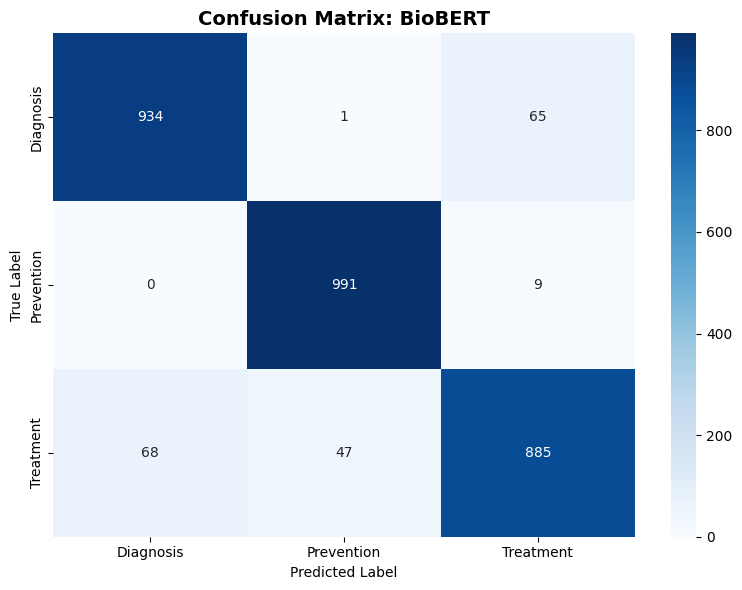

Saved to: /content/drive/MyDrive/medical_classification/figures/biobert_confusion_matrix.png


In [24]:
# Cell 16 — Confusion matrix heatmap
# Uses y_true, y_pred, target_names from Cell 15 and Cell 8

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Confusion Matrix: BioBERT', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

save_path = CONFIG['FIGURES_DIR'] + 'biobert_confusion_matrix.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to: {save_path}')

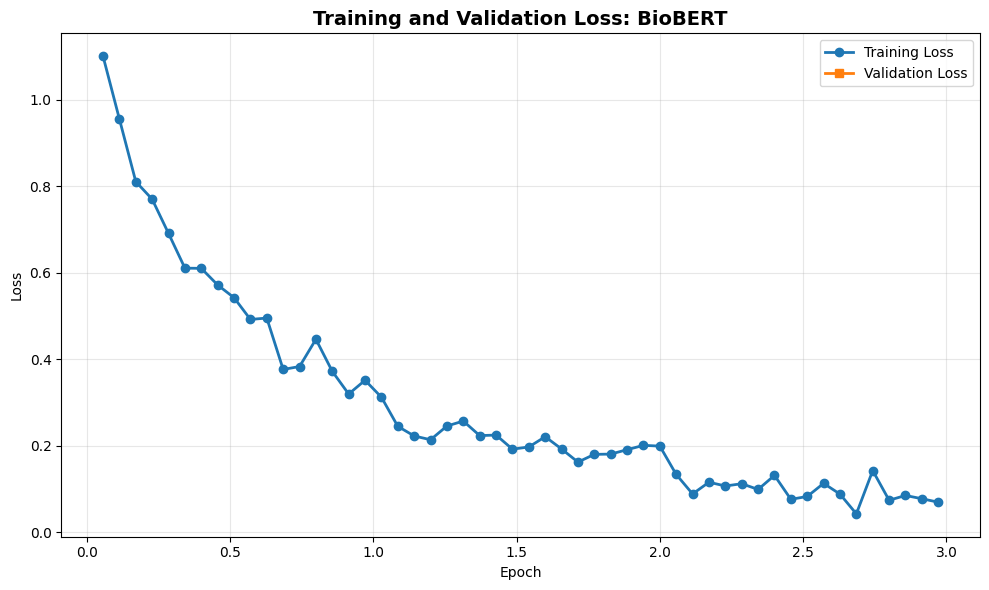

Saved to: /content/drive/MyDrive/medical_classification/figures/biobert_loss_curves.png


In [25]:
# Cell 17 — Training and validation loss curves

history = trainer.state.log_history

# Extract training loss (logged every LOGGING_STEPS steps)
train_loss = [(x['epoch'], x['loss']) for x in history if 'loss' in x and 'eval_loss' not in x]
# Extract validation loss (logged every epoch)
eval_loss  = [(x['epoch'], x['eval_loss']) for x in history if 'eval_loss' in x]

train_epochs  = [x[0] for x in train_loss]
train_losses  = [x[1] for x in train_loss]
eval_epochs   = [x[0] for x in eval_loss]
eval_losses   = [x[1] for x in eval_loss]

plt.figure(figsize=(10, 6))
plt.plot(train_epochs, train_losses, label='Training Loss',   marker='o', linewidth=2)
plt.plot(eval_epochs,  eval_losses,  label='Validation Loss', marker='s', linewidth=2)
plt.title('Training and Validation Loss: BioBERT', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_path = CONFIG['FIGURES_DIR'] + 'biobert_loss_curves.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to: {save_path}')

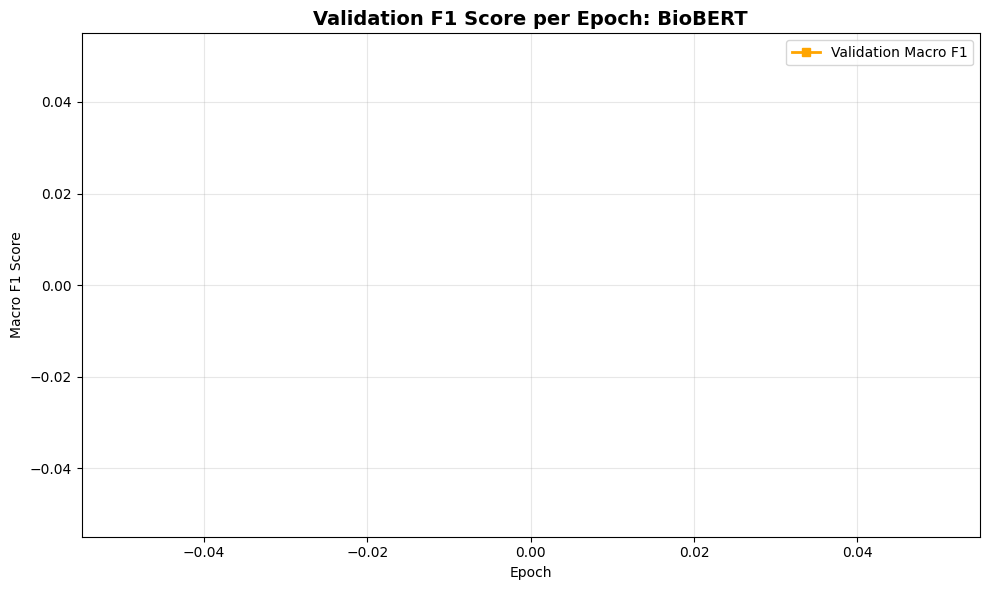

Saved to: /content/drive/MyDrive/medical_classification/figures/biobert_f1_curves.png


In [26]:
# Cell 18 — Validation F1 curve per epoch

eval_f1_data    = [(x['epoch'], x['eval_f1']) for x in history if 'eval_f1' in x]
eval_f1_epochs  = [x[0] for x in eval_f1_data]
eval_f1_scores  = [x[1] for x in eval_f1_data]

plt.figure(figsize=(10, 6))
plt.plot(eval_f1_epochs, eval_f1_scores, label='Validation Macro F1', marker='s', linewidth=2, color='orange')
plt.title('Validation F1 Score per Epoch: BioBERT', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Macro F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_path = CONFIG['FIGURES_DIR'] + 'biobert_f1_curves.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to: {save_path}')

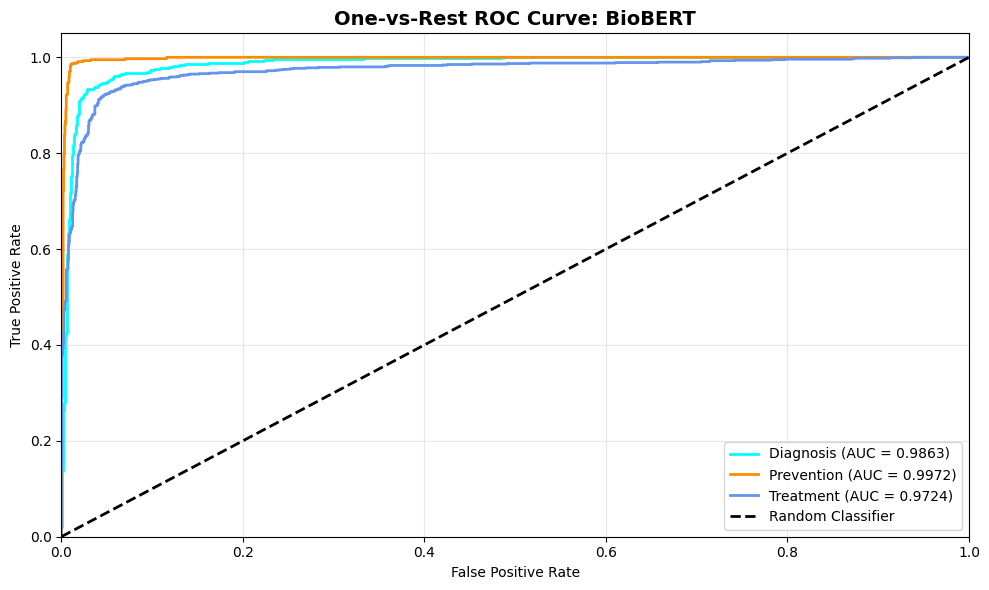

Saved to: /content/drive/MyDrive/medical_classification/figures/biobert_roc_curve.png


In [27]:
# Cell 19 — One-vs-Rest ROC curve for all 3 classes
# Uses y_true, y_prob, target_names from Cells 15 and 8

y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
colors = ['aqua', 'darkorange', 'cornflowerblue']

plt.figure(figsize=(10, 6))
for i, (color, class_name) in enumerate(zip(colors, target_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{class_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curve: BioBERT', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_path = CONFIG['FIGURES_DIR'] + 'biobert_roc_curve.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to: {save_path}')

In [28]:
# Cell 20 — Save final model and tokenizer to Google Drive

print(f'Saving model to: {CONFIG["MODEL_DIR"]}')
trainer.save_model(CONFIG['MODEL_DIR'])
tokenizer.save_pretrained(CONFIG['MODEL_DIR'])
print('Model and tokenizer saved successfully.')
print(f'Location: {CONFIG["MODEL_DIR"]}')

Saving model to: /content/drive/MyDrive/medical_classification/model/biobert_final/


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully.
Location: /content/drive/MyDrive/medical_classification/model/biobert_final/


In [29]:
# Cell 21 — Final results summary table
# Copy the output of this cell into Section 9 of your main notebook

results_summary = pd.DataFrame([{
    'Model'            : 'BioBERT (dmis-lab/biobert-base-cased-v1.2)',
    'Accuracy'         : round(accuracy_score(y_true, y_pred), 4),
    'Precision (Macro)': round(precision_score(y_true, y_pred, average='macro'), 4),
    'Recall (Macro)'   : round(recall_score(y_true, y_pred, average='macro'), 4),
    'F1 Macro'         : round(f1_score(y_true, y_pred, average='macro'), 4),
    'F1 Weighted'      : round(f1_score(y_true, y_pred, average='weighted'), 4),
}])

print('=' * 60)
print('FINAL BIOBERT RESULTS — COPY INTO MAIN NOTEBOOK SECTION 9')
print('=' * 60)
print(results_summary.to_string(index=False))
print('=' * 60)

# Save to CSV on Google Drive
csv_path = CONFIG['RESULTS_DIR'] + 'biobert_final_results.csv'
results_summary.to_csv(csv_path, index=False)
print(f'\nResults saved to: {csv_path}')

FINAL BIOBERT RESULTS — COPY INTO MAIN NOTEBOOK SECTION 9
                                     Model  Accuracy  Precision (Macro)  Recall (Macro)  F1 Macro  F1 Weighted
BioBERT (dmis-lab/biobert-base-cased-v1.2)    0.9367             0.9363          0.9367    0.9362       0.9362

Results saved to: /content/drive/MyDrive/medical_classification/results/biobert_final_results.csv


## Notebook Complete

All steps finished successfully. Here is what was saved to your Google Drive under `/content/drive/MyDrive/medical_classification/`:

| Output | Location |
|--------|----------|
| Confusion matrix | `figures/biobert_confusion_matrix.png` |
| Loss curves | `figures/biobert_loss_curves.png` |
| F1 curves | `figures/biobert_f1_curves.png` |
| ROC curve | `figures/biobert_roc_curve.png` |
| Final model weights | `model/biobert_final/` |
| Results CSV | `results/biobert_final_results.csv` |

**Next step:** Copy the metrics printed in Cell 21 into Section 9 of your main notebook to complete the model comparison table.